In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math
import cv2
import matplotlib.pyplot as plt
import os
import seaborn as sns
import umap
from PIL import Image
from scipy import misc
from os import listdir
from os.path import isfile, join
import numpy as np
from scipy import misc
from random import shuffle
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense
from keras.utils.np_utils import to_categorical

2026-03-11 16:25:19.631748: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773246319.822965      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773246319.883202      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773246320.360500      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773246320.360549      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773246320.360552      55 computation_placer.cc:177] computation placer alr

ModuleNotFoundError: No module named 'keras.utils.np_utils'

In [3]:
os.listdir('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection')

['no', 'yes', 'brain_tumor_dataset']

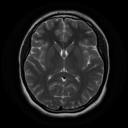

In [5]:
im =Image.open('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/1 no.jpeg').resize((128,128))
im

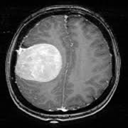

In [6]:
im =Image.open('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes/Y1.jpg').resize((128,128))
im

In [9]:
yes=os.listdir('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes')
no=os.listdir('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no')

In [10]:
data=np.concatenate([yes,no])
len(data)==len(yes)+len(no)

True

In [11]:
target_x=np.full(len(yes),1)
target_y=np.full(len(no),0)
data_target=np.concatenate([target_x,target_y])
len(data_target)==len(target_x)+len(target_y)

True

In [12]:
len(data_target)==len(data)

True

In [13]:
data_target

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [14]:
data

array(['Y115.JPG', 'Y192.JPG', 'Y162.jpg', 'Y9.jpg', 'Y108.jpg',
       'Y155.JPG', 'Y106.jpg', 'Y258.JPG', 'Y103.jpg', 'Y185.jpg',
       'Y180.jpg', 'Y120.JPG', 'Y54.jpg', 'Y165.JPG', 'Y112.JPG',
       'Y99.JPG', 'Y3.jpg', 'Y184.JPG', 'Y82.jpg', 'Y169.jpg', 'Y146.JPG',
       'Y147.JPG', 'Y116.JPG', 'Y27.jpg', 'Y73.jpg', 'Y181.jpg',
       'Y81.jpg', 'Y161.JPG', 'Y17.jpg', 'Y69.jpg', 'Y158.JPG', 'Y32.jpg',
       'Y186.jpg', 'Y259.JPG', 'Y42.jpg', 'Y250.jpg', 'Y58.JPG',
       'Y60.jpg', 'Y252.jpg', 'Y182.JPG', 'Y154.jpg', 'Y79.jpg',
       'Y31.jpg', 'Y98.JPG', 'Y91.jpg', 'Y95.jpg', 'Y22.jpg', 'Y35.jpg',
       'Y33.jpg', 'Y247.JPG', 'Y19.JPG', 'Y160.JPG', 'Y13.jpg', 'Y29.jpg',
       'Y55.jpg', 'Y4.jpg', 'Y50.JPG', 'Y114.JPG', 'Y26.jpg', 'Y257.jpg',
       'Y97.JPG', 'Y14.jpg', 'Y25.jpg', 'Y170.JPG', 'Y51.jpg', 'Y34.jpg',
       'Y39.jpg', 'Y15.jpg', 'Y104.jpg', 'Y187.jpg', 'Y167.JPG',
       'Y40.JPG', 'Y38.jpg', 'Y111.JPG', 'Y37.jpg', 'Y24.jpg', 'Y157.JPG',
       'Y6.jpg', 'Y28

In [17]:
yes_values=os.listdir('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes')
no_values=os.listdir('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no')

In [21]:
X_data =[]
for file in yes_values:
    #face = misc.imread('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes/'+file)
    img = cv2.imread('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes/'+file)
    face = cv2.resize(img, (32, 32) )
    (b, g, r)=cv2.split(face) 
    img=cv2.merge([r,g,b])
    X_data.append(img)

In [22]:
#X_data =[]
for file in no_values:
    #face = misc.imread('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes/'+file)
    img = cv2.imread('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no/'+file)
    face = cv2.resize(img, (32, 32) )
    (b, g, r)=cv2.split(face) 
    img=cv2.merge([r,g,b])
    X_data.append(img)

In [25]:
len(X_data)==len(data)==len(data_target)

True

In [27]:
X = np.squeeze(X_data)


In [28]:
X.shape


(253, 32, 32, 3)

In [29]:
# normalize data
X = X.astype('float32')
X /= 255

In [18]:
#categorical_labels = to_categorical(data_target, num_classes=2)


In [30]:
data_target

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [33]:
(x_train, y_train), (x_test, y_test) = (X[:190],data_target[:190]) , (X[190:] , data_target[190:])
(x_valid , y_valid) = (x_test[:63], y_test[:63])
#(x_test, y_test) = (x_test[63:], y_test[63:])

In [34]:
model = tf.keras.Sequential()

# Must define the input shape in the first layer of the neural network
model.add(tf.keras.layers.Conv2D(filters=16,kernel_size=9, padding='same', activation='relu', input_shape=(32,32,3))) 
model.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model.add(tf.keras.layers.Dropout(0.45))

model.add(tf.keras.layers.Conv2D(filters=16,kernel_size=9,padding='same', activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Conv2D(filters=36, kernel_size=9, padding='same', activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(512, activation='relu'))
model.add(tf.keras.layers.Dropout(0.15))


model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Take a look at the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-11 16:30:29.585514: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │        20,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 36)       │        46,692 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 367,285 (1.40 MB)

 Trainable params: 367,285 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(loss='binary_crossentropy',
             optimizer=tf.keras.optimizers.Adam(),
             metrics=['acc'])

In [37]:
model.fit(x_train,
         y_train,
         batch_size=128,
         epochs=150,
         validation_data=(x_valid, y_valid),)

Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step - acc: 0.3527 - loss: 0.6921 - val_acc: 0.0000e+00 - val_loss: 1.6245
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - acc: 0.8225 - loss: 0.4970 - val_acc: 0.0000e+00 - val_loss: 1.0320
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - acc: 0.8199 - loss: 0.4682 - val_acc: 0.0000e+00 - val_loss: 0.9087
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - acc: 0.8225 - loss: 0.4811 - val_acc: 0.0000e+00 - val_loss: 1.0635
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - acc: 0.8251 - loss: 0.4544 - val_acc: 0.0000e+00 - val_loss: 1.2667
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - acc: 0.8251 - loss: 0.4317 - val_acc: 0.0000e+00 - val_loss: 1.1343
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - acc: 0.8095 - loss: 0.4551 - val_acc: 0.0000e+00 - val_loss: 0.9937
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - acc: 0.8095 - loss: 0.4593 - val_acc: 0.0000e+00 - val_loss: 1.0230
Epoch 9/150
2/2 ━━━━━━━━━━━━━━━━

In [40]:
pip install pydot graphviz


Note: you may need to restart the kernel to use updated packages.


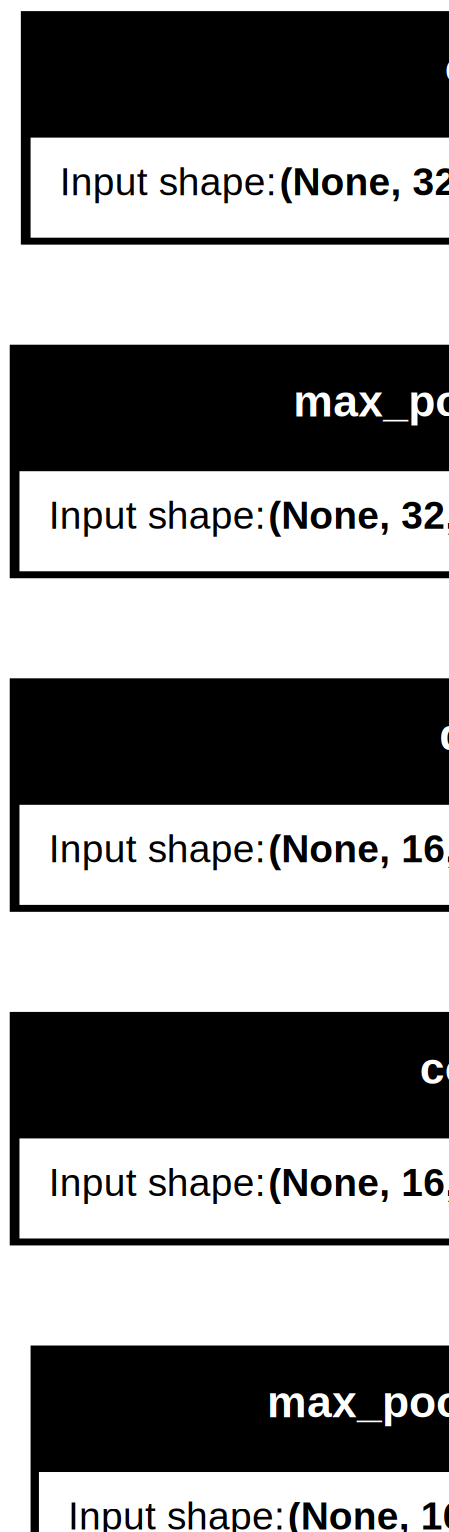

In [42]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png', show_shapes=True)


from IPython.display import SVG

SVG(model_to_dot(model,show_shapes = True).create(prog='dot', format='svg'))

In [43]:
# Evaluate the model on test set
score = model.evaluate(x_test, y_test, verbose=0)

# Print test accuracy
print('\n', 'Test accuracy:', score[1])


 Test accuracy: 0.761904776096344


In [44]:
labels =["Yes",  # index 0
        "No",      # index 1
        ]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


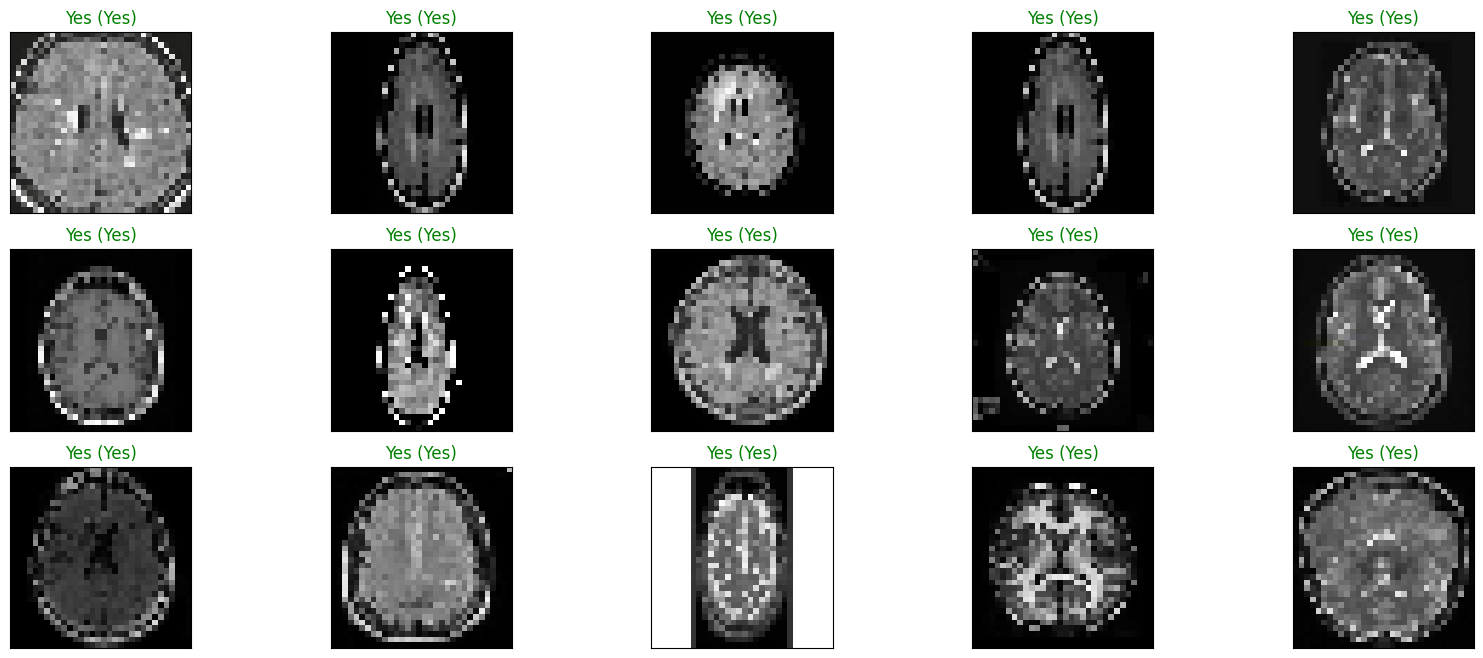

In [45]:
y_hat = model.predict(x_test)

# Plot a random sample of 10 test images, their predicted labels and ground truth
figure = plt.figure(figsize=(20, 8))
for i, index in enumerate(np.random.choice(x_test.shape[0], size=15, replace=False)):
    ax = figure.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
    # Display each image
    ax.imshow(np.squeeze(x_test[index]))
    predict_index = np.argmax(y_hat[index])
    true_index = np.argmax(y_test[index])
    # Set the title for each image
    ax.set_title("{} ({})".format(labels[predict_index], 
                                  labels[true_index]),
                                  color=("green" if predict_index == true_index else "red"))
plt.show()